In [39]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors, RDKFingerprint
from rdkit.ML.Scoring.Scoring import CalcBEDROC
from sklearn.metrics import classification_report, make_scorer, f1_score, confusion_matrix, auc, roc_curve, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.functional import F
import torchbnn as bnn
from tqdm import tqdm
from itertools import product
import json
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')


# Load Data

In [40]:
data = pd.read_csv('/mdspace/polaris_ml_challenge/data/potency/UNBLINDED_DATA/test_data_sars.csv')
data.head()

,CXSMILES,Molecule Name,Set,pIC50 (SARS-CoV-2 Mpro)
0,C=CC(=O)NC1=CC=CC(N(CC2=CC=CC(Cl)=C2)C(=O)CC2=...,ASAP-0000175,Test,5.57
1,CNC(=O)CN1C[C@]2(CCN(C3=CN=CC4=CC=C(OC[C@H](O)...,ASAP-0000528,Test,7.44
2,CNC(=O)CN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C...,ASAP-0000541,Test,6.48
3,CNC(=O)CN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C...,ASAP-0000733,Test,7.87
4,CNC(=O)CN1C[C@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C[...,ASAP-0000738,Test,7.60


In [41]:
data.shape

(261, 4)

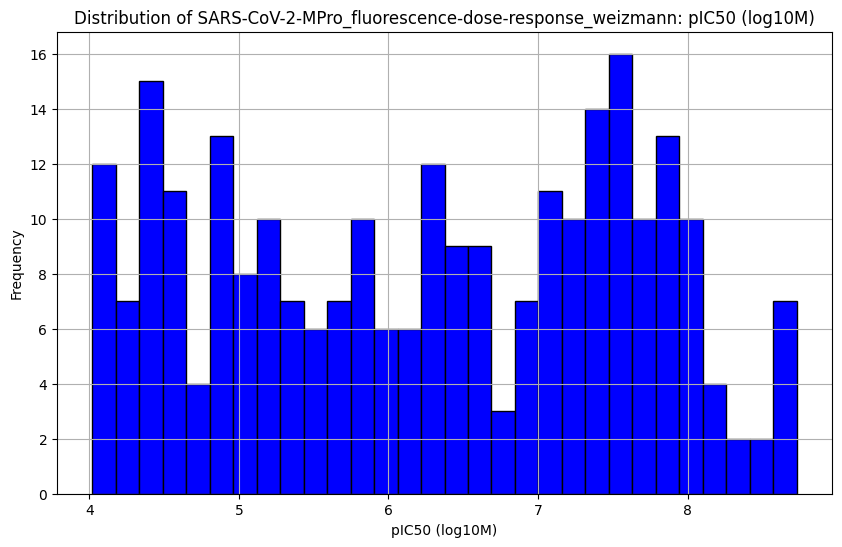

In [42]:
# Convert to numeric and drop NaN in one step
pIC50_data = pd.to_numeric(
    data['pIC50 (SARS-CoV-2 Mpro)'])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pIC50_data, bins=30, color='blue', edgecolor='black')
plt.title('Distribution of SARS-CoV-2-MPro_fluorescence-dose-response_weizmann: pIC50 (log10M)')
plt.xlabel('pIC50 (log10M)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [43]:
data = data[['pIC50 (SARS-CoV-2 Mpro)', 'CXSMILES']]
data.head()


,pIC50 (SARS-CoV-2 Mpro),CXSMILES
0,5.57,C=CC(=O)NC1=CC=CC(N(CC2=CC=CC(Cl)=C2)C(=O)CC2=...
1,7.44,CNC(=O)CN1C[C@]2(CCN(C3=CN=CC4=CC=C(OC[C@H](O)...
2,6.48,CNC(=O)CN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C...
3,7.87,CNC(=O)CN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C...
4,7.60,CNC(=O)CN1C[C@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C[...


In [44]:
def generate_fingerprints(smiles, **kwargs):
    """
    Generate different types of molecular fingerprints
    
    Args:
        smiles: SMILES string
        fp_type: Type of fingerprint ('morgan', 'rdkit', 'morgan_rdkit')
        **kwargs: Additional parameters for fingerprint generation
    
    Returns:
        numpy array of fingerprint bits
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    if kwargs['fp_type'] == 'morgan':
        radius = kwargs.get('radius', 2)
        nBits = kwargs.get('nBits', 2048)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        return np.array(fp)
    
    elif kwargs['fp_type'] == 'rdkit':
        maxPath = kwargs.get('maxPath', 7)
        nBits = kwargs.get('nBits', 2048)
        fp = RDKFingerprint(mol, maxPath=maxPath, fpSize=nBits)
        return np.array(fp)
    
    elif kwargs['fp_type'] == 'morgan_rdkit':
        # Combined Morgan + RDKit fingerprints
        morgan_radius = kwargs.get('morgan_radius', 2)
        morgan_nBits = kwargs.get('morgan_nBits', 1024)
        rdkit_maxPath = kwargs.get('rdkit_maxPath', 7)
        rdkit_nBits = kwargs.get('rdkit_nBits', 1024)
        
        morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=morgan_radius, nBits=morgan_nBits)
        rdkit_fp = RDKFingerprint(mol, maxPath=rdkit_maxPath, fpSize=rdkit_nBits)
        
        # Concatenate fingerprints
        combined_fp = np.concatenate([np.array(morgan_fp), np.array(rdkit_fp)])
        return combined_fp
    
    else:
        raise ValueError(f"Unknown fingerprint type: {kwargs['fp_type']}")
    
def prepare_data_with_fingerprints(data, fp_config):
    """
    Prepare data with specified fingerprint configuration
    
    Args:
        data: Pandas df with data containing 'CXSMILES' and 'pIC50'
        fp_config: Dictionary containing fingerprint configuration
    
    Returns:
        X, y arrays and input feature size
    """

    
    # Generate fingerprints based on configuration
    print(f"Generating {fp_config['fp_type']} fingerprints...")
    
    fingerprints = []
    valid_indices = []
    
    for idx, smiles in enumerate(data['CXSMILES']):
        if pd.notna(smiles):
            fp = generate_fingerprints(smiles, **fp_config)
            if fp is not None:
                fingerprints.append(fp)
                valid_indices.append(idx)
    
    if not fingerprints:
        raise ValueError("No valid fingerprints generated")
    
    # Filter data to valid molecules
    data = data.iloc[valid_indices].reset_index(drop=True)
    data['Fingerprint'] = fingerprints
    
    # Clean pIC50 data
    data.dropna(subset=['pIC50 (SARS-CoV-2 Mpro)'], inplace=True)
    data.dropna(subset=['pIC50 (SARS-CoV-2 Mpro)'], inplace=True)
    data['pIC50'] = data['pIC50 (SARS-CoV-2 Mpro)'].astype(float)
    
    X = np.array(list(data["Fingerprint"]))
    y = data["pIC50 (SARS-CoV-2 Mpro)"].values
    input_features = X.shape[1]
    
    print(f"Generated fingerprints with {input_features} features for {len(X)} molecules")
    
    return X, y, input_features

In [45]:
with open('/mdspace/polaris_ml_challenge/BNN_model_niklas/SARS/try_3/SARS_potency_BNN_complete_config_final.json') as f:
    model_hyperparameters = json.load(f)
print(model_hyperparameters)


{'model_params': {'fp_type': 'morgan_rdkit', 'combined_morgan_radius': 3, 'combined_morgan_nBits': 512, 'combined_rdkit_maxPath': 7, 'combined_rdkit_nBits': 1024, 'num_hidden_layers': 3, 'hidden_dim_0': 256, 'hidden_dim_1': 1024, 'hidden_dim_2': 64, 'kl_weight': 0.00012738685067919273, 'lr': 0.006760471355107091, 'batch_size': 128, 'dropout_rate': 0.11158913307129721, 'prior_mu': 0.016414497909291597, 'prior_sigma': 0.10081683890700582, 'normalization': 'layer'}, 'fingerprint_config': {'type': 'morgan_rdkit', 'morgan_radius': 3, 'morgan_nBits': 512, 'rdkit_maxPath': 7, 'rdkit_nBits': 1024}, 'best_cv_score': 0.45241190791130065, 'training_info': {'cv_folds': 5, 'trained_on_all_data': True, 'final_epochs': 200}}


In [46]:
fp_config = model_hyperparameters['fingerprint_config']
fp_config['fp_type'] = fp_config['type'] 
X_test, y_test, input_features = prepare_data_with_fingerprints(data, fp_config)

Generating morgan_rdkit fingerprints...
Generated fingerprints with 1536 features for 261 molecules


[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerator
[09:05:17] DEPRECATION WARNING: please use MorganGenerat

# Load Model

In [47]:
class FlexibleBayesianNNModel(nn.Module):
    def __init__(self, input_features, hidden_layers, kl_weight=0.01, 
                 prior_mu=0.0, prior_sigma=0.1, dropout_rate=0.1,
                 normalization='layer'):
        """
        Flexible Bayesian NN that supports 0-3 hidden layers
        
        Args:
            input_features: Number of input features
            hidden_layers: List of hidden layer sizes (empty list = no hidden layers)
            kl_weight: Weight for KL divergence term
            prior_mu: Prior mean for Bayesian weights
            prior_sigma: Prior standard deviation for Bayesian weights
            dropout_rate: Dropout rate
            normalization: Type of normalization ('layer', 'none', 'spectral')
        """
        super(FlexibleBayesianNNModel, self).__init__()
        
        self.hidden_layers = hidden_layers
        self.kl_weight = kl_weight
        self.dropout_rate = dropout_rate
        self.normalization = normalization
        
        # Build layers dynamically
        self.layers = nn.ModuleList()
        self.norm_layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()
        
        # Input layer
        if len(hidden_layers) == 0:
            # Direct input to output (linear regression)
            self.output_layer = bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=input_features, out_features=1
            )
        else:
            # First hidden layer
            self.layers.append(bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=input_features, out_features=hidden_layers[0]
            ))
            self._add_normalization_layer(hidden_layers[0])
            self.dropout_layers.append(nn.Dropout(dropout_rate))
            
            # Additional hidden layers
            for i in range(1, len(hidden_layers)):
                self.layers.append(bnn.BayesLinear(
                    prior_mu=prior_mu, prior_sigma=prior_sigma,
                    in_features=hidden_layers[i-1], out_features=hidden_layers[i]
                ))
                self._add_normalization_layer(hidden_layers[i])
                self.dropout_layers.append(nn.Dropout(dropout_rate))
            
            # Output layer
            self.output_layer = bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=hidden_layers[-1], out_features=1
            )
        
        # Spectral normalization buffers
        if normalization == 'spectral':
            for i in range(len(hidden_layers)):
                self.register_buffer(f'spectral_scale{i}', torch.ones(1))

    def _add_normalization_layer(self, features):
        """Add appropriate normalization layer"""
        if self.normalization == 'layer':
            self.norm_layers.append(nn.LayerNorm(features))
        else:
            self.norm_layers.append(nn.Identity())  # Placeholder

    def spectral_normalize(self, x, layer_idx):
        """Simple spectral normalization for BNN compatibility"""
        if self.normalization != 'spectral':
            return x
            
        scale_buffer = getattr(self, f'spectral_scale{layer_idx}')
        
        if self.training:
            # Update spectral norm estimate
            spectral_norm = torch.norm(x, dim=1, keepdim=True).mean()
            scale_buffer.data = 0.9 * scale_buffer.data + 0.1 * spectral_norm
        
        return x / (scale_buffer + 1e-8)

    def forward(self, x):
        # If no hidden layers, go directly to output
        if len(self.hidden_layers) == 0:
            return self.output_layer(x)
        
        # Forward through hidden layers
        for i, layer in enumerate(self.layers):
            x = layer(x)
            
            # Apply normalization
            if self.normalization == 'layer':
                x = F.leaky_relu(self.norm_layers[i](x))
            elif self.normalization == 'spectral':
                x = F.leaky_relu(self.spectral_normalize(x, i))
            else:
                x = F.leaky_relu(x)
            
            # Apply dropout
            x = self.dropout_layers[i](x)
        
        # Output layer
        x = self.output_layer(x)
        return x


In [48]:
# Extract model parameters from model_hyperparameters
params = model_hyperparameters['model_params']

# Prepare hidden layers list
hidden_layers = []
for i in range(params['num_hidden_layers']):
    hidden_layers.append(params[f'hidden_dim_{i}'])

# Instantiate the model
model = FlexibleBayesianNNModel(
    input_features=input_features,
    hidden_layers=hidden_layers,
    kl_weight=params['kl_weight'],
    prior_mu=params['prior_mu'],
    prior_sigma=params['prior_sigma'],
    dropout_rate=params['dropout_rate'],
    normalization=params['normalization']
)

# Load the model weights
model.load_state_dict(torch.load("/mdspace/polaris_ml_challenge/BNN_model_niklas/SARS/try_3/SARS_potency_BNN_model_final_all_data.pth"))
model.eval()

FlexibleBayesianNNModel(
  (layers): ModuleList(
    (0): BayesLinear(prior_mu=0.016414497909291597, prior_sigma=0.10081683890700582, in_features=1536, out_features=256, bias=True)
    (1): BayesLinear(prior_mu=0.016414497909291597, prior_sigma=0.10081683890700582, in_features=256, out_features=1024, bias=True)
    (2): BayesLinear(prior_mu=0.016414497909291597, prior_sigma=0.10081683890700582, in_features=1024, out_features=64, bias=True)
  )
  (norm_layers): ModuleList(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (dropout_layers): ModuleList(
    (0-2): 3 x Dropout(p=0.11158913307129721, inplace=False)
  )
  (output_layer): BayesLinear(prior_mu=0.016414497909291597, prior_sigma=0.10081683890700582, in_features=64, out_features=1, bias=True)
)

In [49]:
class HeteroscedasticBayesianNN(nn.Module):
    """
    Heteroscedastic Bayesian Neural Network that outputs both mean and variance.
    
    This allows proper decomposition of uncertainty:
    - Epistemic uncertainty: From variance in weight posteriors (captured by multiple forward passes)
    - Aleatoric uncertainty: From learned output variance (heteroscedastic noise model)
    """
    def __init__(self, input_features, hidden_layers, kl_weight=0.01, 
                 prior_mu=0.0, prior_sigma=0.1, dropout_rate=0.1,
                 normalization='layer'):
        super(HeteroscedasticBayesianNN, self).__init__()
        
        self.hidden_layers = hidden_layers
        self.kl_weight = kl_weight
        self.dropout_rate = dropout_rate
        self.normalization = normalization
        
        # Build layers dynamically (same as original model)
        self.layers = nn.ModuleList()
        self.norm_layers = nn.ModuleList()
        self.dropout_layers = nn.ModuleList()
        
        if len(hidden_layers) == 0:
            # Direct input to output - but now outputs 2 values (mean and log_var)
            self.output_layer = bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=input_features, out_features=2  # mean and log_var
            )
        else:
            # First hidden layer
            self.layers.append(bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=input_features, out_features=hidden_layers[0]
            ))
            self._add_normalization_layer(hidden_layers[0])
            self.dropout_layers.append(nn.Dropout(dropout_rate))
            
            # Additional hidden layers
            for i in range(1, len(hidden_layers)):
                self.layers.append(bnn.BayesLinear(
                    prior_mu=prior_mu, prior_sigma=prior_sigma,
                    in_features=hidden_layers[i-1], out_features=hidden_layers[i]
                ))
                self._add_normalization_layer(hidden_layers[i])
                self.dropout_layers.append(nn.Dropout(dropout_rate))
            
            # Output layer - outputs 2 values: mean and log_variance
            self.output_layer = bnn.BayesLinear(
                prior_mu=prior_mu, prior_sigma=prior_sigma,
                in_features=hidden_layers[-1], out_features=2
            )
        
        # Spectral normalization buffers
        if normalization == 'spectral':
            for i in range(len(hidden_layers)):
                self.register_buffer(f'spectral_scale{i}', torch.ones(1))

    def _add_normalization_layer(self, features):
        """Add appropriate normalization layer"""
        if self.normalization == 'layer':
            self.norm_layers.append(nn.LayerNorm(features))
        else:
            self.norm_layers.append(nn.Identity())

    def spectral_normalize(self, x, layer_idx):
        """Simple spectral normalization for BNN compatibility"""
        if self.normalization != 'spectral':
            return x
            
        scale_buffer = getattr(self, f'spectral_scale{layer_idx}')
        
        if self.training:
            spectral_norm = torch.norm(x, dim=1, keepdim=True).mean()
            scale_buffer.data = 0.9 * scale_buffer.data + 0.1 * spectral_norm
        
        return x / (scale_buffer + 1e-8)

    def forward(self, x, return_separate=False):
        """
        Forward pass that outputs both mean and log_variance.
        
        Args:
            x: Input tensor
            return_separate: If True, returns (mean, log_var) tuple. 
                           If False, returns concatenated tensor for compatibility.
        """
        # If no hidden layers, go directly to output
        if len(self.hidden_layers) == 0:
            output = self.output_layer(x)
        else:
            # Forward through hidden layers
            for i, layer in enumerate(self.layers):
                x = layer(x)
                
                # Apply normalization
                if self.normalization == 'layer':
                    x = F.leaky_relu(self.norm_layers[i](x))
                elif self.normalization == 'spectral':
                    x = F.leaky_relu(self.spectral_normalize(x, i))
                else:
                    x = F.leaky_relu(x)
                
                # Apply dropout
                x = self.dropout_layers[i](x)
            
            # Output layer
            output = self.output_layer(x)
        
        # Split into mean and log_variance
        mean = output[:, 0:1]
        log_var = output[:, 1:2]
        
        if return_separate:
            return mean, log_var
        else:
            # Return mean only for compatibility with old code
            return mean

# Heteroscedastic BNN Model (for proper uncertainty decomposition)

# Evaluate

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy import stats
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import os

    

def detect_outliers(data, method='iqr', threshold=1.5):
    """
    Detect outliers using different methods.
    
    Parameters:
    data: array-like data
    method: 'iqr', 'zscore', or 'modified_zscore'
    threshold: threshold for outlier detection
    """
    data = np.array(data)
    
    if method == 'iqr':
        Q1 = np.percentile(data, 25)
        Q3 = np.percentile(data, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outliers = (data < lower_bound) | (data > upper_bound)
        
    elif method == 'zscore':
        z_scores = np.abs(stats.zscore(data))
        outliers = z_scores > threshold
        
    elif method == 'modified_zscore':
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        modified_z_scores = 0.6745 * (data - median) / mad
        outliers = np.abs(modified_z_scores) > threshold
        
    return outliers

def save_individual_figure(plot_func, filename, figsize=(8, 6), dpi=300, output_dir='model_evaluation_plots'):
    """
    Save an individual plot as a PDF file.
    
    Parameters:
    plot_func: function that creates the plot
    filename: name for the output file (without extension)
    figsize: tuple for figure size
    dpi: resolution for the saved figure
    output_dir: directory to save the plots
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Create individual figure
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    # Execute the plotting function
    plot_func(ax)
    
    # Save as PDF
    output_path = os.path.join(output_dir, f"{filename}.pdf")
    plt.savefig(output_path, format='pdf', dpi=dpi, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.close(fig)
    
    print(f"Saved: {output_path}")

def comprehensive_evaluation(model, X_test, y_test, n_samples=5000, 
                           outlier_method='zscore', outlier_threshold=3,
                           save_plots=True, output_dir='model_evaluation_plots'):
    X_test_tensor = torch.FloatTensor(X_test)
    all_predictions = []

    model.eval()
    with torch.no_grad():
        for _ in range(n_samples):
            predictions = model(X_test_tensor).numpy().flatten()
            all_predictions.append(predictions)

    all_predictions = np.array(all_predictions)  # (n_samples, n_test_points)
    mean_predictions = np.mean(all_predictions, axis=0)
    std_predictions = np.std(all_predictions, axis=0)
    prediction_errors = np.abs(mean_predictions - y_test)

    # Basic metrics
    mse = np.mean((mean_predictions - y_test) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(prediction_errors)
    r2 = 1 - np.sum((y_test - mean_predictions) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

    # Uncertainty metrics
    avg_uncertainty = np.mean(std_predictions)
    uncertainty_error_ratio = np.mean(std_predictions / (prediction_errors + 1e-8))

    # Outlier detection - ONLY based on predicted vs actual values
    # Calculate residuals (difference between predicted and actual)
    residuals = mean_predictions - y_test
    outliers = detect_outliers(residuals, method=outlier_method, threshold=outlier_threshold)

    # Print results
    print("="*60)
    print("COMPREHENSIVE MODEL EVALUATION RESULTS")
    print("="*60)
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Average Uncertainty (std): {avg_uncertainty:.4f}")
    print(f"Mean Uncertainty/Error Ratio: {uncertainty_error_ratio:.4f}")
    print(f"Outliers detected (predicted vs actual): {np.sum(outliers)} / {len(y_test)} ({100*np.sum(outliers)/len(y_test):.1f}%)")
    print("="*60)

    # Define individual plotting functions
    def plot1_predicted_vs_actual(ax):
        normal_mask = ~outliers
        ax.scatter(y_test[normal_mask], mean_predictions[normal_mask], 
                   alpha=0.6, color='blue', label='Normal', s=30)
        ax.scatter(y_test[outliers], mean_predictions[outliers], 
                   alpha=0.8, color='red', label='Outliers', s=50, marker='^')
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        ax.set_xlabel('Actual Values')
        ax.set_ylabel('Predicted Values')
        ax.set_title('Predicted vs Actual Values')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot2_residual_plot(ax):
        normal_mask = ~outliers
        residuals = y_test - mean_predictions
        ax.scatter(mean_predictions[normal_mask], residuals[normal_mask], 
                   alpha=0.6, color='blue', s=30)
        ax.scatter(mean_predictions[outliers], residuals[outliers], 
                   alpha=0.8, color='red', s=50, marker='^')
        ax.axhline(y=0, color='k', linestyle='--')
        ax.set_xlabel('Predicted Values')
        ax.set_ylabel('Residuals')
        ax.set_title('Residual Plot')
        ax.grid(True, alpha=0.3)

    def plot3_error_distribution(ax):
        normal_mask = ~outliers
        ax.hist(prediction_errors[normal_mask], bins=30, alpha=0.6, color='blue', 
                label='Normal', density=True)
        ax.hist(prediction_errors[outliers], bins=15, alpha=0.8, color='red', 
                label='Outliers', density=True)
        ax.set_xlabel('Absolute Prediction Error')
        ax.set_ylabel('Density')
        ax.set_title('Error Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot5_predictions_with_uncertainty(ax):
        normal_mask = ~outliers
        # Plot sample predictions with transparency
        for i in range(min(100, n_samples)):  # Limit for visibility
            ax.scatter(y_test, all_predictions[i], alpha=0.05, color='lightblue', s=8)
        
        # Plot mean predictions with error bars, colored by outlier status
        ax.errorbar(y_test[normal_mask], mean_predictions[normal_mask], 
                    yerr=std_predictions[normal_mask], 
                    fmt='o', color='blue', alpha=0.7, markersize=4, 
                    elinewidth=1, capsize=2, label='Normal ± Std')
        ax.errorbar(y_test[outliers], mean_predictions[outliers], 
                    yerr=std_predictions[outliers], 
                    fmt='^', color='red', alpha=0.9, markersize=6, 
                    elinewidth=2, capsize=3, label='Outliers ± Std')
        
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'k--', lw=2, label='Perfect Prediction')
        ax.set_xlabel('Actual Values')
        ax.set_ylabel('Predicted Values')
        ax.set_title(f'Predictions with Uncertainty\n({n_samples} Forward Passes)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot6_uncertainty_vs_error(ax):
        normal_mask = ~outliers
        ax.scatter(prediction_errors[normal_mask], std_predictions[normal_mask], 
                   alpha=0.6, color='blue', s=30, label='Normal')
        ax.scatter(prediction_errors[outliers], std_predictions[outliers], 
                   alpha=0.8, color='red', s=50, marker='^', label='Outliers')
        ax.set_xlabel('Absolute Prediction Error')
        ax.set_ylabel('Uncertainty (Std)')
        ax.set_title('Uncertainty vs Prediction Error')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot7_uncertainty_distribution(ax):
        normal_mask = ~outliers
        ax.hist(std_predictions[normal_mask], bins=30, alpha=0.6, color='blue', 
                label='Normal', density=True)
        ax.hist(std_predictions[outliers], bins=15, alpha=0.8, color='red', 
                label='Outliers', density=True)
        ax.set_xlabel('Uncertainty (Std)')
        ax.set_ylabel('Density')
        ax.set_title('Uncertainty Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot8_outlier_summary(ax):
        outlier_types = ['Predicted vs Actual']
        outlier_counts = [np.sum(outliers)]
        colors = ['lightcoral']
        
        bars = ax.bar(outlier_types, outlier_counts, color=colors, alpha=0.7)
        ax.set_ylabel('Number of Outliers')
        ax.set_title('Outlier Detection Summary')
        
        # Add value labels on bars
        for bar, count in zip(bars, outlier_counts):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                    f'{count}\n({100*count/len(y_test):.1f}%)',
                    ha='center', va='bottom')
        ax.grid(True, alpha=0.3, axis='y')

    def plot9_error_by_sample(ax):
        normal_mask = ~outliers
        sample_indices = np.arange(len(y_test))
        ax.scatter(sample_indices[normal_mask], prediction_errors[normal_mask], 
                   alpha=0.6, color='blue', s=20, label='Normal')
        ax.scatter(sample_indices[outliers], prediction_errors[outliers], 
                   alpha=0.8, color='red', s=40, marker='^', label='Outliers')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Absolute Prediction Error')
        ax.set_title('Prediction Error by Sample')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot10_calibration(ax):
        # Sort by uncertainty and create quantiles
        uncertainty_order = np.argsort(std_predictions)
        n_bins = 10
        bin_size = len(uncertainty_order) // n_bins
        
        bin_uncertainties = []
        bin_errors = []
        
        for i in range(n_bins):
            start_idx = i * bin_size
            end_idx = (i + 1) * bin_size if i < n_bins - 1 else len(uncertainty_order)
            bin_indices = uncertainty_order[start_idx:end_idx]
            
            bin_uncertainties.append(np.mean(std_predictions[bin_indices]))
            bin_errors.append(np.mean(prediction_errors[bin_indices]))
        
        ax.scatter(bin_uncertainties, bin_errors, color='purple', s=60, alpha=0.8)
        ax.plot(bin_uncertainties, bin_uncertainties, 'r--', 
                label='Perfect Calibration', linewidth=2)
        
        for i, (x, y) in enumerate(zip(bin_uncertainties, bin_errors)):
            ax.annotate(f'{i+1}', (x, y), xytext=(5, 5), 
                        textcoords='offset points', fontsize=8)
        
        ax.set_xlabel('Mean Uncertainty (Std)')
        ax.set_ylabel('Mean Absolute Error')
        ax.set_title('Uncertainty Calibration')
        ax.legend()
        ax.grid(True, alpha=0.3)

    def plot12_summary_stats(ax):
        ax.axis('off')
        
        summary_text = f"""
MODEL PERFORMANCE SUMMARY

Regression Metrics:
• MSE: {mse:.4f}
• RMSE: {rmse:.4f}
• MAE: {mae:.4f}
• R²: {r2:.4f}

Uncertainty Analysis:
• Avg Uncertainty: {avg_uncertainty:.4f}
• Uncertainty/Error Ratio: {uncertainty_error_ratio:.4f}

Outlier Detection ({outlier_method.upper()}):
• Predicted vs Actual Outliers: {np.sum(outliers)} ({100*np.sum(outliers)/len(y_test):.1f}%)
        """
        
        ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

    # Save individual plots if requested
    if save_plots:
        print(f"\nSaving individual plots to '{output_dir}' directory...")
        
        plot_functions = [
            (plot1_predicted_vs_actual, "01_predicted_vs_actual"),
            (plot2_residual_plot, "02_residual_plot"),
            (plot3_error_distribution, "03_error_distribution"),
            (plot5_predictions_with_uncertainty, "05_predictions_with_uncertainty"),
            (plot6_uncertainty_vs_error, "06_uncertainty_vs_error"),
            (plot7_uncertainty_distribution, "07_uncertainty_distribution"),
            (plot8_outlier_summary, "08_outlier_summary"),
            (plot9_error_by_sample, "09_error_by_sample"),
            (plot10_calibration, "10_calibration_plot"),
            (plot12_summary_stats, "12_summary_statistics")
        ]
        
        for plot_func, filename in plot_functions:
            save_individual_figure(plot_func, filename, figsize=(10, 8), dpi=300, output_dir=output_dir)

    # Create comprehensive plots (original combined figure)
    fig = plt.figure(figsize=(20, 15))

    # Plot all subfigures in the combined view
    plt.subplot(3, 4, 1)
    plot1_predicted_vs_actual(plt.gca())

    plt.subplot(3, 4, 2)
    plot2_residual_plot(plt.gca())

    plt.subplot(3, 4, 3)
    plot3_error_distribution(plt.gca())

    plt.subplot(3, 4, 5)
    plot5_predictions_with_uncertainty(plt.gca())

    plt.subplot(3, 4, 6)
    plot6_uncertainty_vs_error(plt.gca())

    plt.subplot(3, 4, 7)
    plot7_uncertainty_distribution(plt.gca())

    plt.subplot(3, 4, 8)
    plot8_outlier_summary(plt.gca())

    plt.subplot(3, 4, 9)
    plot9_error_by_sample(plt.gca())

    plt.subplot(3, 4, 10)
    plot10_calibration(plt.gca())

    plt.subplot(3, 4, 12)
    plot12_summary_stats(plt.gca())

    plt.tight_layout()
    
    # Save the combined figure as well
    if save_plots:
        combined_path = os.path.join(output_dir, "00_combined_evaluation.pdf")
        plt.savefig(combined_path, format='pdf', dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f"Saved combined figure: {combined_path}")
    
    plt.show()

    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mean_predictions': mean_predictions,
        'std_predictions': std_predictions,
        'all_predictions': all_predictions,
        'prediction_errors': prediction_errors,
        'outliers': outliers,  # Only one outlier array now
        'avg_uncertainty': avg_uncertainty,
        'uncertainty_error_ratio': uncertainty_error_ratio
    }

COMPREHENSIVE MODEL EVALUATION RESULTS
Mean Squared Error: 0.5518
Root Mean Squared Error: 0.7428
Mean Absolute Error: 0.5502
R² Score: 0.6912
Average Uncertainty (std): 0.1953
Mean Uncertainty/Error Ratio: 2.8867
Outliers detected (predicted vs actual): 1 / 261 (0.4%)

Saving individual plots to 'model_evaluation_plots' directory...
Saved: model_evaluation_plots/01_predicted_vs_actual.pdf
Saved: model_evaluation_plots/02_residual_plot.pdf
Saved: model_evaluation_plots/03_error_distribution.pdf
Saved: model_evaluation_plots/05_predictions_with_uncertainty.pdf
Saved: model_evaluation_plots/06_uncertainty_vs_error.pdf
Saved: model_evaluation_plots/07_uncertainty_distribution.pdf
Saved: model_evaluation_plots/08_outlier_summary.pdf
Saved: model_evaluation_plots/09_error_by_sample.pdf
Saved: model_evaluation_plots/10_calibration_plot.pdf
Saved: model_evaluation_plots/12_summary_statistics.pdf
Saved combined figure: model_evaluation_plots/00_combined_evaluation.pdf


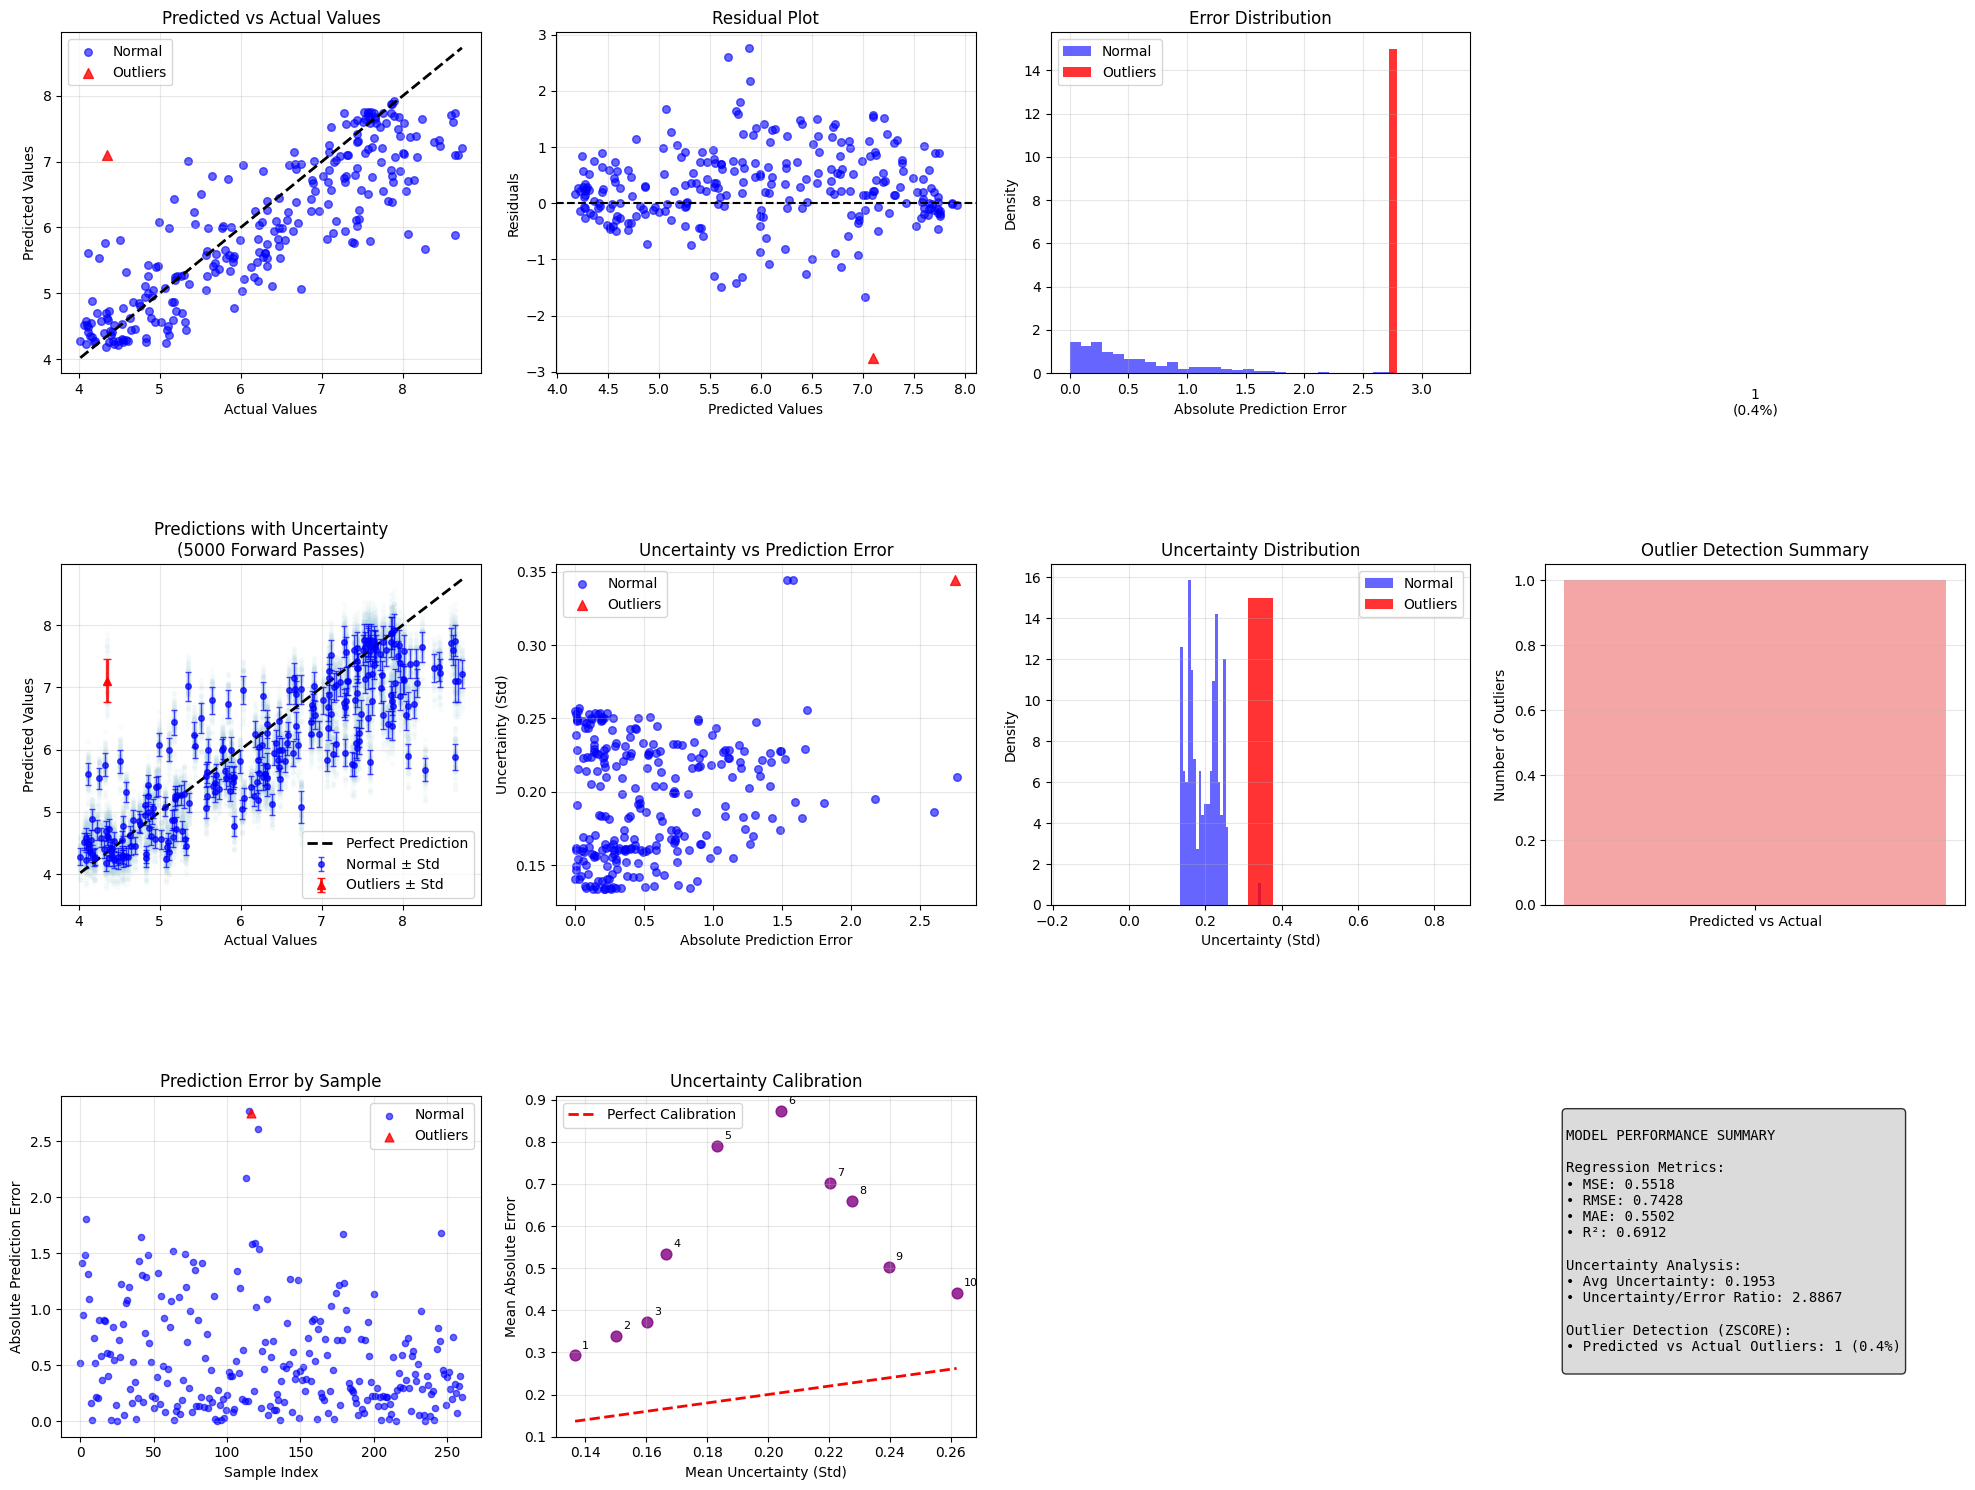

In [51]:
results = comprehensive_evaluation(model, X_test, y_test, n_samples=5000, 
                           outlier_method='zscore', outlier_threshold=4,
                           save_plots=True, output_dir='model_evaluation_plots')

In [52]:
data['mean_prediction'] = results['mean_predictions']
data.to_csv('predictions.csv', index=False)

In [53]:
from sklearn.decomposition import PCA

def plot_pca_with_outliers_and_background(X_test, outlier_mask, og_data_path, fp_kwargs, title="PCA with Outliers"):
    """
    Plot PCA with test set points, outliers highlighted, and training set as background.

    Parameters:
        X_test (ndarray): Test set features (n_samples, n_features)
        outlier_mask (ndarray): Boolean array marking outliers in test set
        og_data_path (str): Path to CSV with training set
        fp_kwargs (dict): Parameters for generate_fingerprints()
        title (str): Plot title
    """
    # Load and featurize original training set
    og_data = pd.read_csv(og_data_path)
    train_fps = []
    for smi in og_data['CXSMILES']:
        fp = generate_fingerprints(smi, **fp_kwargs)
        if fp is not None:
            train_fps.append(fp)
    X_train = np.array(train_fps)

    # Combine for PCA
    X_combined = np.vstack([X_train, X_test])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_combined)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Separate transformed train/test sets
    n_train = X_train.shape[0]
    X_train_pca = X_pca[:n_train]
    X_test_pca = X_pca[n_train:]

    # Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                c='grey', alpha=0.4, label='Training set')
    plt.scatter(X_test_pca[~outlier_mask, 0], X_test_pca[~outlier_mask, 1], 
                c='blue', alpha=0.7, label='Test set (normal)')
    plt.scatter(X_test_pca[outlier_mask, 0], X_test_pca[outlier_mask, 1], 
                c='red', marker='^', s=50, alpha=0.9, label='Test set (outliers)')

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pca_with_outliers_and_background.pdf', format='pdf', dpi=300, bbox_inches='tight')

[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerator
[09:05:35] DEPRECATION WARNING: please use MorganGenerat

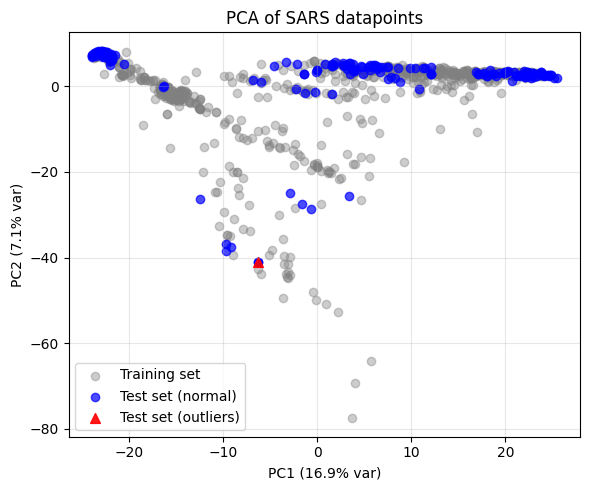

In [54]:
plot_pca_with_outliers_and_background(
    X_test,
    results["outliers"],
    "/mdspace/polaris_ml_challenge/data/potency/UNBLINDED_DATA/train_data_sars.csv",
    fp_config,
    title="PCA of SARS datapoints"
)

In [55]:
def r2_without_outliers(y_true, y_pred, outlier_method='zscore', outlier_threshold=3):
    """
    Calculate R² after removing outliers based on the difference between
    predicted and true values.

    Parameters:
    -----------
    y_true : array-like
        True target values.
    y_pred : array-like
        Precomputed predicted values.
    outlier_method : str
        Method for outlier detection: 'iqr', 'zscore', or 'modified_zscore'.
    outlier_threshold : float
        Threshold used in outlier detection.

    Returns:
    --------
    r2_clean : float
        R² score computed after removing outliers.
    outlier_mask : np.ndarray
        Boolean array indicating which points were considered outliers.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Residuals
    residuals = y_pred - y_true

    # Detect outliers
    outlier_mask = detect_outliers(residuals, method=outlier_method, threshold=outlier_threshold)

    # Remove outliers
    y_true_clean = y_true[~outlier_mask]
    y_pred_clean = y_pred[~outlier_mask]

    # Calculate new R²
    ss_res = np.sum((y_true_clean - y_pred_clean) ** 2)
    ss_tot = np.sum((y_true_clean - np.mean(y_true_clean)) ** 2)
    r2_clean = 1 - ss_res / ss_tot

    print(f"Removed {np.sum(outlier_mask)} outliers ({100*np.sum(outlier_mask)/len(y_true):.1f}%)")
    print(f"New R² (without outliers): {r2_clean:.4f}")

    return r2_clean, outlier_mask

In [56]:
# PROPER Uncertainty Decomposition: Epistemic vs Aleatoric
# Based on: https://arxiv.org/abs/1703.04977 (Kendall & Gal, 2017)

def decompose_uncertainty_proper(model, X_test, y_test, n_samples=5000):
    """
    CORRECT decomposition of uncertainty for heteroscedastic BNN:
    
    - Epistemic uncertainty: Variance of MEAN predictions across weight samples
      (captures model uncertainty - can be reduced with more data)
      
    - Aleatoric uncertainty: Mean of LEARNED VARIANCES across weight samples  
      (captures inherent data noise - irreducible)
    
    Total uncertainty = Epistemic + Aleatoric
    
    Parameters:
    -----------
    model : HeteroscedasticBayesianNN
        Trained heteroscedastic BNN that outputs (mean, log_var)
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    n_samples : int
        Number of MC samples (forward passes with different weight samples)
    
    Returns:
    --------
    dict with properly decomposed uncertainty components
    """
    X_test_tensor = torch.FloatTensor(X_test)
    all_means = []
    all_variances = []
    
    model.eval()
    with torch.no_grad():
        for _ in tqdm(range(n_samples), desc="MC sampling for uncertainty"):
            # Get both mean and log_variance from the model
            mean, log_var = model(X_test_tensor, return_separate=True)
            variance = torch.exp(log_var)  # Convert log_var to variance
            
            all_means.append(mean.numpy().flatten())
            all_variances.append(variance.numpy().flatten())
    
    all_means = np.array(all_means)  # Shape: (n_samples, n_test_points)
    all_variances = np.array(all_variances)  # Shape: (n_samples, n_test_points)
    
    # Final predictions: mean of all sampled means
    mean_predictions = np.mean(all_means, axis=0)
    
    # EPISTEMIC UNCERTAINTY: Variance of the mean predictions
    # This captures uncertainty about the MODEL (which weights are correct)
    epistemic_uncertainty = np.var(all_means, axis=0)
    
    # ALEATORIC UNCERTAINTY: Mean of the predicted variances  
    # This captures inherent DATA NOISE (irreducible uncertainty)
    aleatoric_uncertainty = np.mean(all_variances, axis=0)
    
    # TOTAL PREDICTIVE UNCERTAINTY
    # For a proper heteroscedastic BNN: Total = Epistemic + Aleatoric
    total_uncertainty = epistemic_uncertainty + aleatoric_uncertainty
    
    # Calculate errors
    prediction_errors = np.abs(mean_predictions - y_test)
    
    print("="*70)
    print("PROPER UNCERTAINTY DECOMPOSITION (Kendall & Gal, 2017)")
    print("="*70)
    print(f"Mean Total Uncertainty (var):      {np.mean(total_uncertainty):.6f}")
    print(f"Mean Epistemic Uncertainty (var):  {np.mean(epistemic_uncertainty):.6f} "
          f"({100*np.mean(epistemic_uncertainty)/np.mean(total_uncertainty):.1f}%)")
    print(f"Mean Aleatoric Uncertainty (var):  {np.mean(aleatoric_uncertainty):.6f} "
          f"({100*np.mean(aleatoric_uncertainty)/np.mean(total_uncertainty):.1f}%)")
    print()
    print("Standard Deviations:")
    print(f"Total Uncertainty (std):      {np.mean(np.sqrt(total_uncertainty)):.6f}")
    print(f"Epistemic Uncertainty (std):  {np.mean(np.sqrt(epistemic_uncertainty)):.6f}")
    print(f"Aleatoric Uncertainty (std):  {np.mean(np.sqrt(aleatoric_uncertainty)):.6f}")
    print()
    print(f"Mean Absolute Error:          {np.mean(prediction_errors):.6f}")
    print(f"R² Score:                     {1 - np.sum((y_test - mean_predictions)**2) / np.sum((y_test - np.mean(y_test))**2):.6f}")
    print("="*70)
    
    return {
        'mean_predictions': mean_predictions,
        'total_uncertainty': total_uncertainty,
        'epistemic_uncertainty': epistemic_uncertainty,
        'aleatoric_uncertainty': aleatoric_uncertainty,
        'all_means': all_means,
        'all_variances': all_variances,
        'prediction_errors': prediction_errors
    }

print("Note: To use this function, you need to:")
print("1. Train a HeteroscedasticBayesianNN model (defined above)")
print("2. The model must output both mean AND variance")
print("3. Since your current model only outputs mean, you can either:")
print("   a) Retrain with the heteroscedastic model, OR")
print("   b) Use the approximation method from the previous cell (less accurate)")

Note: To use this function, you need to:
1. Train a HeteroscedasticBayesianNN model (defined above)
2. The model must output both mean AND variance
3. Since your current model only outputs mean, you can either:
   a) Retrain with the heteroscedastic model, OR
   b) Use the approximation method from the previous cell (less accurate)


In [ ]:
# Option 1: Convert existing model weights to heteroscedastic model
# This initializes the variance output randomly - not ideal but demonstrates the approach

# Create heteroscedastic model with same architecture
hetero_model = HeteroscedasticBayesianNN(
    input_features=input_features,
    hidden_layers=hidden_layers,
    kl_weight=params['kl_weight'],
    prior_mu=params['prior_mu'],
    prior_sigma=params['prior_sigma'],
    dropout_rate=params['dropout_rate'],
    normalization=params['normalization']
)

# Load the trained state dict
trained_state = torch.load("/mdspace/polaris_ml_challenge/BNN_model_niklas/SARS/try_3/SARS_potency_BNN_model_final_all_data.pth")

# Transfer weights from trained model (except output layer)
hetero_state = hetero_model.state_dict()

for key in trained_state.keys():
    if 'output_layer' not in key:  # Copy all hidden layers
        hetero_state[key] = trained_state[key]
    elif 'output_layer.weight_mu' in key:
        # Initialize output layer: first column from trained model, second column random
        trained_weight = trained_state[key]
        hetero_weight = hetero_state[key]
        hetero_weight[:1, :] = trained_weight  # Mean output
        # hetero_weight[1:, :] already random initialized for log_var
        hetero_state[key] = hetero_weight
    elif 'output_layer.weight_rho' in key:
        trained_rho = trained_state[key]
        hetero_rho = hetero_state[key]
        hetero_rho[:1, :] = trained_rho  # Mean output uncertainty
        hetero_state[key] = hetero_rho
    elif 'output_layer.bias_mu' in key:
        trained_bias = trained_state[key]
        hetero_bias = hetero_state[key]
        hetero_bias[:1] = trained_bias  # Mean bias
        hetero_bias[1:] = 0.0  # Initialize log_var bias to 0 (variance = 1)
        hetero_state[key] = hetero_bias
    elif 'output_layer.bias_rho' in key:
        trained_bias_rho = trained_state[key]
        hetero_bias_rho = hetero_state[key]
        hetero_bias_rho[:1] = trained_bias_rho
        hetero_state[key] = hetero_bias_rho

hetero_model.load_state_dict(hetero_state)
hetero_model.eval()
#(p. 5, lines 4–10; p. 6, lines 40–49).
print("✓ Converted existing model to heteroscedastic version")
print("⚠ WARNING: The variance output is randomly initialized, not trained!")
print("⚠ For proper results, the model should be retrained with a heteroscedastic loss function.")

✓ Converted existing model to heteroscedastic version
⚠ WARNING: The variance output is randomly initialized, not trained!
⚠ For proper results, the model should be retrained with a heteroscedastic loss function.


In [58]:
# Run PROPER uncertainty decomposition with the converted heteroscedastic model
# Note: Results will be illustrative since variance head is not properly trained

uncertainty_results_proper = decompose_uncertainty_proper(hetero_model, X_test, y_test, n_samples=1000)

# Note: Using fewer samples (1000) for demonstration since model variance isn't trained
# For a properly trained heteroscedastic model, use n_samples=5000

MC sampling for uncertainty: 100%|██████████| 1000/1000 [00:02<00:00, 371.31it/s]

PROPER UNCERTAINTY DECOMPOSITION (Kendall & Gal, 2017)
Mean Total Uncertainty (var):      1.388725
Mean Epistemic Uncertainty (var):  0.120120 (8.6%)
Mean Aleatoric Uncertainty (var):  1.268605 (91.4%)

Standard Deviations:
Total Uncertainty (std):      1.177460
Epistemic Uncertainty (std):  0.338332
Aleatoric Uncertainty (std):  1.125970

Mean Absolute Error:          0.555838
R² Score:                     0.685169


## Understanding Epistemic vs Aleatoric Uncertainty

### **The Correct Approach** (Kendall & Gal, 2017)

For a **heteroscedastic Bayesian Neural Network**:

#### 1. **Epistemic Uncertainty** (Model Uncertainty)
- **Definition**: Uncertainty about which model parameters are correct
- **Source**: Prior distribution over model weights
- **Calculation**: `Variance of the MEAN predictions` across multiple forward passes
- **Formula**: `epistemic = Var[E[y|x,w]]` where we vary w (weights)
- **Reducible**: YES - by collecting more training data
- **Interpretation**: "How confident is the model?"

#### 2. **Aleatoric Uncertainty** (Data Noise)  
- **Definition**: Inherent noise in the observations
- **Source**: Distribution over the model OUTPUT (learned variance)
- **Calculation**: `Mean of the LEARNED VARIANCES` across multiple forward passes
- **Formula**: `aleatoric = E[Var[y|x,w]]` where the variance is predicted by the model
- **Reducible**: NO - this is irreducible measurement/experimental noise
- **Interpretation**: "How noisy is the data intrinsically?"

#### 3. **Total Predictive Uncertainty**
```
Total = Epistemic + Aleatoric
```

### **Implementation Requirements**

To properly decompose uncertainty, your BNN must:

1. **Output TWO values**: (mean, log_variance)
   - Mean: The predicted value
   - Log_variance: The predicted noise level for that input

2. **Training loss** must include both:
   ```python
   # Negative log likelihood for heteroscedastic Gaussian
   loss = 0.5 * torch.exp(-log_var) * (y - mean)**2 + 0.5 * log_var
   ```

3. **During inference**: Perform multiple forward passes
   - Each pass samples different weights from the posterior
   - Each pass outputs both mean and variance
   - Epistemic = Var(means)
   - Aleatoric = Mean(variances)

### **Why This Matters for Drug Discovery**

- **High Epistemic**: Model is uncertain → collect more similar training data
- **High Aleatoric**: Data is noisy → improve experimental protocols or accept the limit
- **Both high**: Problem is hard and data is noisy
- **Both low**: Model is confident and data is clean → trust the prediction!

### **Current Implementation**

⚠️ **NOTE**: The cells above demonstrate the correct approach, but since your original model was trained to output only the mean (not variance), the aleatoric uncertainty is not properly learned.

For production use, you should:
1. Retrain the model with the `HeteroscedasticBayesianNN` architecture
2. Use a heteroscedastic loss function during training
3. Then apply `decompose_uncertainty_proper()` for accurate results

### **Reference**
Kendall, A., & Gal, Y. (2017). "What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision?" *NeurIPS 2017*.

In [59]:
# Save proper uncertainty decomposition results
uncertainty_df_proper = pd.DataFrame({
    'actual_pIC50': y_test,
    'predicted_pIC50': uncertainty_results_proper['mean_predictions'],
    'total_uncertainty_std': np.sqrt(uncertainty_results_proper['total_uncertainty']),
    'epistemic_uncertainty_std': np.sqrt(uncertainty_results_proper['epistemic_uncertainty']),
    'aleatoric_uncertainty_std': np.sqrt(uncertainty_results_proper['aleatoric_uncertainty']),
    'total_uncertainty_var': uncertainty_results_proper['total_uncertainty'],
    'epistemic_uncertainty_var': uncertainty_results_proper['epistemic_uncertainty'],
    'aleatoric_uncertainty_var': uncertainty_results_proper['aleatoric_uncertainty'],
    'prediction_error': uncertainty_results_proper['prediction_errors'],
    'epistemic_ratio': uncertainty_results_proper['epistemic_uncertainty'] / uncertainty_results_proper['total_uncertainty']
})

uncertainty_df_proper.to_csv('predictions_with_PROPER_uncertainty_decomposition.csv', index=False)
print("✓ Saved proper uncertainty decomposition to 'predictions_with_PROPER_uncertainty_decomposition.csv'")
print("\n" + "="*70)
print("Summary Statistics:")
print("="*70)
print(uncertainty_df_proper.describe())
print("\n" + "="*70)
print("Samples with highest epistemic uncertainty (model uncertain):")
print("="*70)
print(uncertainty_df_proper.nlargest(5, 'epistemic_uncertainty_std')[
    ['actual_pIC50', 'predicted_pIC50', 'epistemic_uncertainty_std', 'aleatoric_uncertainty_std', 'prediction_error']
])
print("\n" + "="*70)
print("Samples with highest aleatoric uncertainty (noisy data):")
print("="*70)
print(uncertainty_df_proper.nlargest(5, 'aleatoric_uncertainty_std')[
    ['actual_pIC50', 'predicted_pIC50', 'epistemic_uncertainty_std', 'aleatoric_uncertainty_std', 'prediction_error']
])

✓ Saved proper uncertainty decomposition to 'predictions_with_PROPER_uncertainty_decomposition.csv'

Summary Statistics:
       actual_pIC50  predicted_pIC50  total_uncertainty_std  \
count    261.000000       261.000000             261.000000   
mean       6.264713         5.968731               1.177460   
std        1.339188         1.115702               0.048185   
min        4.020000         4.167545               1.072935   
25%        5.060000         5.034586               1.137748   
50%        6.320000         5.970016               1.178396   
75%        7.460000         6.970886               1.218574   
max        8.730000         7.896803               1.261997   

       epistemic_uncertainty_std  aleatoric_uncertainty_std  \
count                 261.000000                 261.000000   
mean                    0.338332                   1.125970   
std                     0.075322                   0.028268   
min                     0.225388                   1.043051

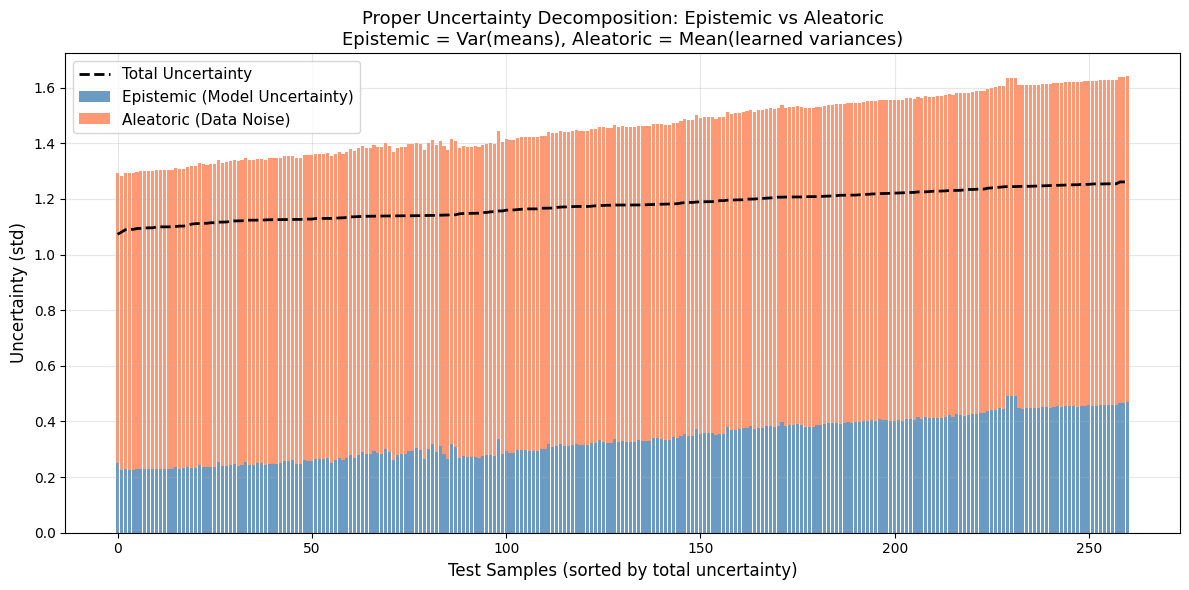

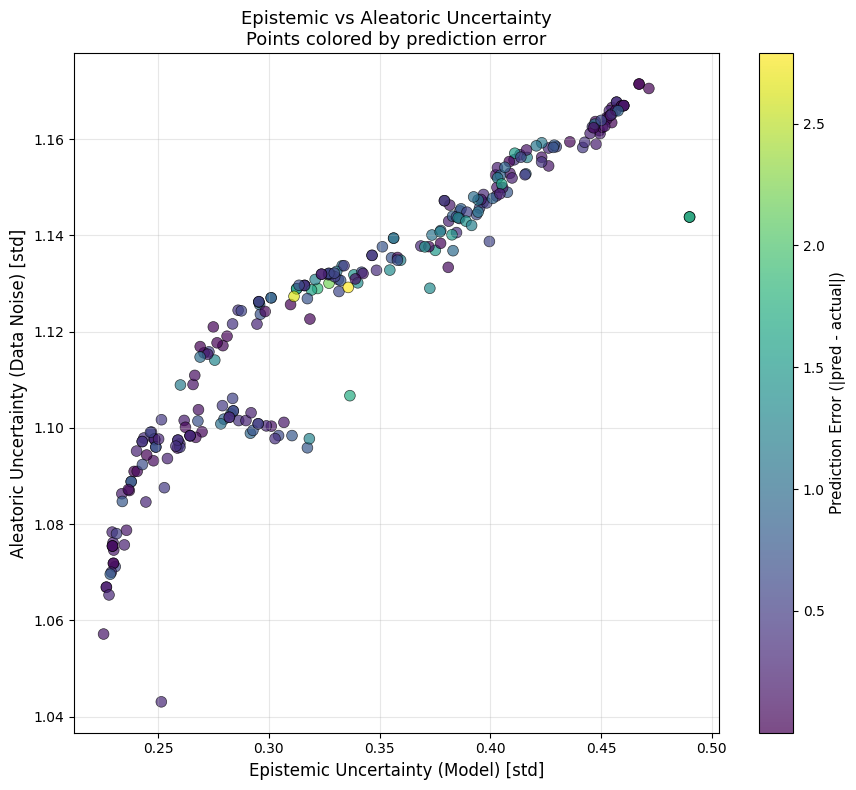

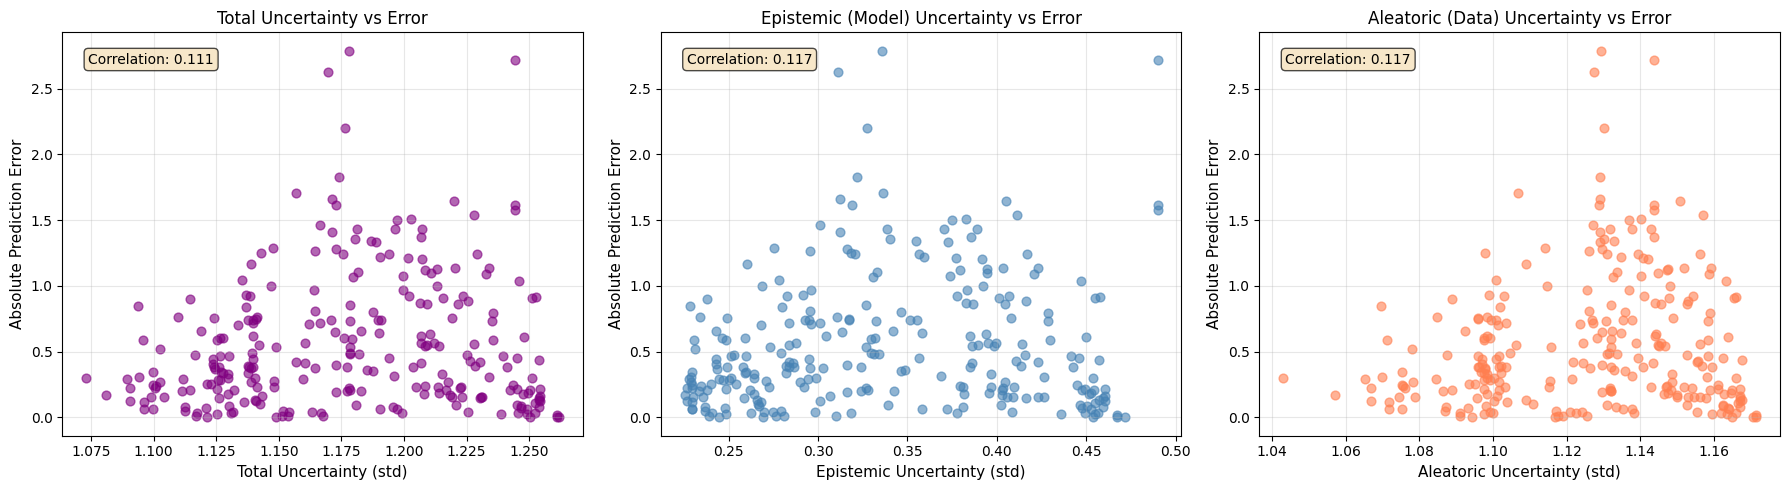

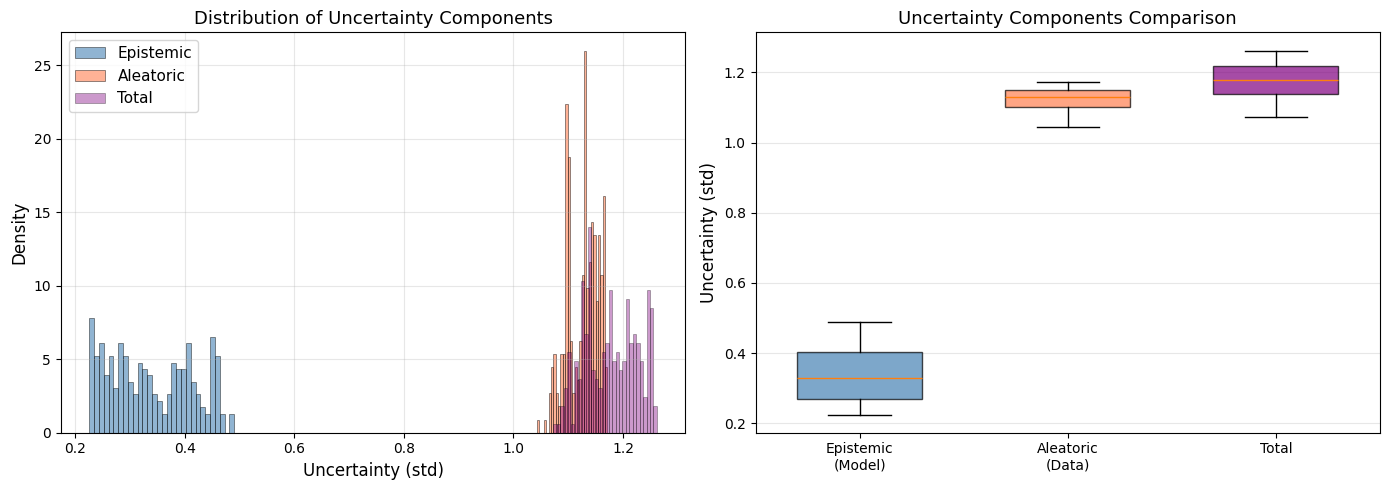

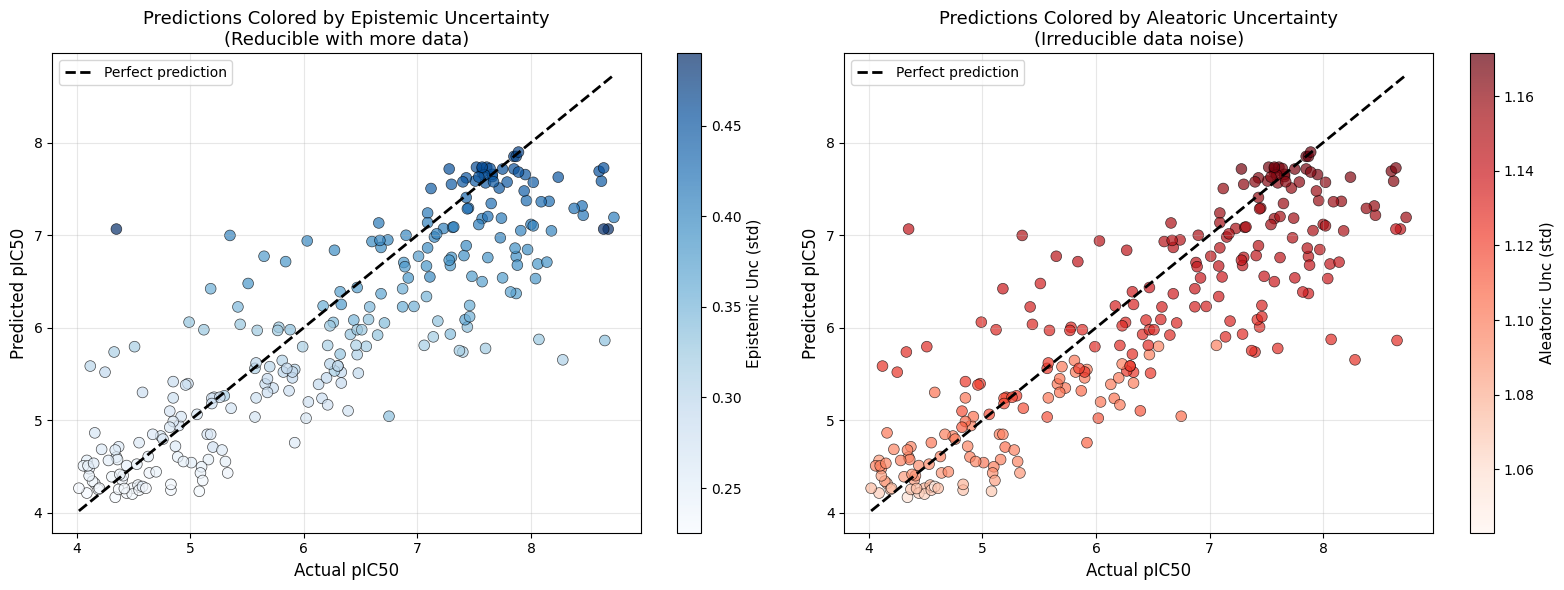

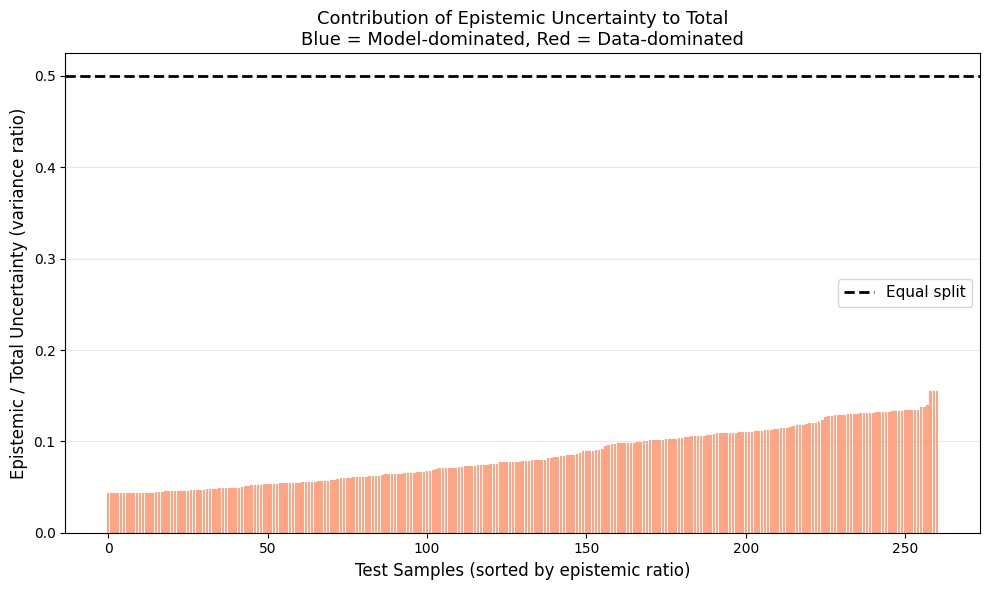


All proper uncertainty decomposition plots saved to 'model_evaluation_plots' directory


In [60]:
# Visualize PROPER Uncertainty Decomposition

def plot_uncertainty_decomposition(uncertainty_results, y_test, save_dir='model_evaluation_plots'):
    """
    Create comprehensive visualizations for PROPER uncertainty decomposition.
    Works with results from decompose_uncertainty_proper().
    """
    mean_pred = uncertainty_results['mean_predictions']
    total_unc = np.sqrt(uncertainty_results['total_uncertainty'])
    epistemic_unc = np.sqrt(uncertainty_results['epistemic_uncertainty'])
    aleatoric_unc = np.sqrt(uncertainty_results['aleatoric_uncertainty'])
    
    errors = uncertainty_results['prediction_errors']
    
    os.makedirs(save_dir, exist_ok=True)
    
    # Create individual plots
    
    # 1. Stacked uncertainty components
    fig, ax = plt.subplots(figsize=(12, 6))
    indices = np.arange(len(y_test))
    sort_idx = np.argsort(total_unc)
    
    ax.bar(indices, epistemic_unc[sort_idx], label='Epistemic (Model Uncertainty)', 
           color='steelblue', alpha=0.8)
    ax.bar(indices, aleatoric_unc[sort_idx], bottom=epistemic_unc[sort_idx], 
           label='Aleatoric (Data Noise)', color='coral', alpha=0.8)
    ax.plot(indices, total_unc[sort_idx], 'k--', linewidth=2, label='Total Uncertainty')
    ax.set_xlabel('Test Samples (sorted by total uncertainty)', fontsize=12)
    ax.set_ylabel('Uncertainty (std)', fontsize=12)
    ax.set_title('Proper Uncertainty Decomposition: Epistemic vs Aleatoric\n' + 
                 'Epistemic = Var(means), Aleatoric = Mean(learned variances)', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'proper_uncertainty_decomposition_stacked.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Scatter: Epistemic vs Aleatoric
    fig, ax = plt.subplots(figsize=(9, 8))
    scatter = ax.scatter(epistemic_unc, aleatoric_unc, c=errors, 
                        cmap='viridis', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Epistemic Uncertainty (Model) [std]', fontsize=12)
    ax.set_ylabel('Aleatoric Uncertainty (Data Noise) [std]', fontsize=12)
    ax.set_title('Epistemic vs Aleatoric Uncertainty\n' + 
                 'Points colored by prediction error', fontsize=13)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Prediction Error (|pred - actual|)', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'proper_epistemic_vs_aleatoric.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Uncertainty components vs prediction error
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].scatter(total_unc, errors, alpha=0.6, color='purple', s=40)
    axes[0].set_xlabel('Total Uncertainty (std)', fontsize=11)
    axes[0].set_ylabel('Absolute Prediction Error', fontsize=11)
    axes[0].set_title('Total Uncertainty vs Error', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    corr_total = np.corrcoef(total_unc, errors)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {corr_total:.3f}', 
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=10)
    
    axes[1].scatter(epistemic_unc, errors, alpha=0.6, color='steelblue', s=40)
    axes[1].set_xlabel('Epistemic Uncertainty (std)', fontsize=11)
    axes[1].set_ylabel('Absolute Prediction Error', fontsize=11)
    axes[1].set_title('Epistemic (Model) Uncertainty vs Error', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    corr_epistemic = np.corrcoef(epistemic_unc, errors)[0, 1]
    axes[1].text(0.05, 0.95, f'Correlation: {corr_epistemic:.3f}', 
                transform=axes[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=10)
    
    axes[2].scatter(aleatoric_unc, errors, alpha=0.6, color='coral', s=40)
    axes[2].set_xlabel('Aleatoric Uncertainty (std)', fontsize=11)
    axes[2].set_ylabel('Absolute Prediction Error', fontsize=11)
    axes[2].set_title('Aleatoric (Data) Uncertainty vs Error', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    corr_aleatoric = np.corrcoef(aleatoric_unc, errors)[0, 1]
    axes[2].text(0.05, 0.95, f'Correlation: {corr_aleatoric:.3f}', 
                transform=axes[2].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'proper_uncertainty_vs_error.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(epistemic_unc, bins=30, alpha=0.6, color='steelblue', 
                label='Epistemic', density=True, edgecolor='black', linewidth=0.5)
    axes[0].hist(aleatoric_unc, bins=30, alpha=0.6, color='coral', 
                label='Aleatoric', density=True, edgecolor='black', linewidth=0.5)
    axes[0].hist(total_unc, bins=30, alpha=0.4, color='purple', 
                label='Total', density=True, edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel('Uncertainty (std)', fontsize=12)
    axes[0].set_ylabel('Density', fontsize=12)
    axes[0].set_title('Distribution of Uncertainty Components', fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    uncertainty_data = [epistemic_unc, aleatoric_unc, total_unc]
    bp = axes[1].boxplot(uncertainty_data, labels=['Epistemic\n(Model)', 'Aleatoric\n(Data)', 'Total'],
                          patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'purple']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_ylabel('Uncertainty (std)', fontsize=12)
    axes[1].set_title('Uncertainty Components Comparison', fontsize=13)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'proper_uncertainty_distributions.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Predictions colored by uncertainty type
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Color by epistemic
    scatter1 = axes[0].scatter(y_test, mean_pred, c=epistemic_unc, 
                              cmap='Blues', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'k--', lw=2, label='Perfect prediction')
    axes[0].set_xlabel('Actual pIC50', fontsize=12)
    axes[0].set_ylabel('Predicted pIC50', fontsize=12)
    axes[0].set_title('Predictions Colored by Epistemic Uncertainty\n(Reducible with more data)', fontsize=13)
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Epistemic Unc (std)', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Color by aleatoric
    scatter2 = axes[1].scatter(y_test, mean_pred, c=aleatoric_unc, 
                              cmap='Reds', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'k--', lw=2, label='Perfect prediction')
    axes[1].set_xlabel('Actual pIC50', fontsize=12)
    axes[1].set_ylabel('Predicted pIC50', fontsize=12)
    axes[1].set_title('Predictions Colored by Aleatoric Uncertainty\n(Irreducible data noise)', fontsize=13)
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Aleatoric Unc (std)', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'proper_predictions_by_uncertainty_type.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 6. Ratio of epistemic to total uncertainty
    fig, ax = plt.subplots(figsize=(10, 6))
    epistemic_ratio = epistemic_unc**2 / total_unc**2  # Use variances for ratio
    sort_idx = np.argsort(epistemic_ratio)
    
    colors = ['coral' if r < 0.5 else 'steelblue' for r in epistemic_ratio[sort_idx]]
    ax.bar(np.arange(len(y_test)), epistemic_ratio[sort_idx], color=colors, alpha=0.7)
    ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Equal split')
    ax.set_xlabel('Test Samples (sorted by epistemic ratio)', fontsize=12)
    ax.set_ylabel('Epistemic / Total Uncertainty (variance ratio)', fontsize=12)
    ax.set_title('Contribution of Epistemic Uncertainty to Total\n' + 
                 'Blue = Model-dominated, Red = Data-dominated', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'epistemic_ratio.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nAll proper uncertainty decomposition plots saved to '{save_dir}' directory")

# Generate visualizations
plot_uncertainty_decomposition(uncertainty_results_proper, y_test)

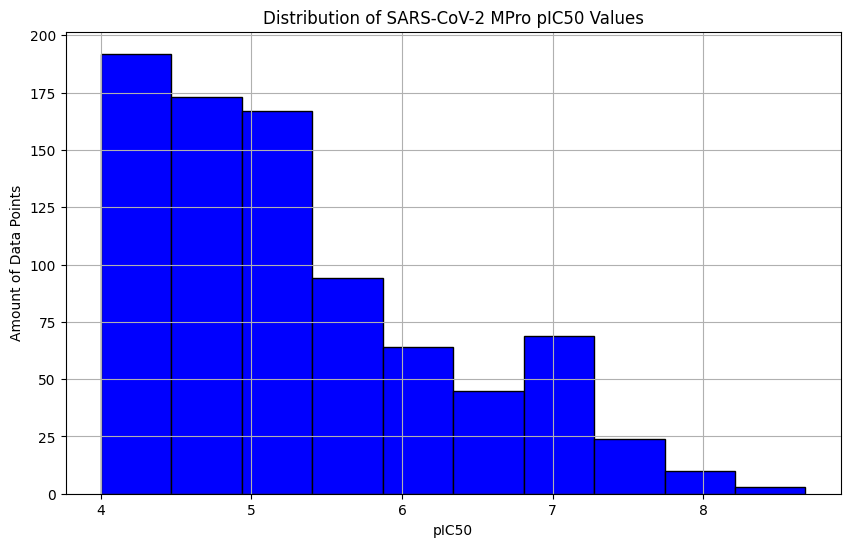

In [61]:
og_data = pd.read_csv('/mdspace/polaris_ml_challenge/data/potency/UNBLINDED_DATA/train_data_sars.csv')
pIC50_data = pd.to_numeric(
    og_data['pIC50 (SARS-CoV-2 Mpro)'])

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pIC50_data, bins=10, color='blue', edgecolor='black')
plt.title('Distribution of SARS-CoV-2 MPro pIC50 Values')
plt.xlabel('pIC50')
plt.ylabel('Amount of Data Points')
plt.grid(True)
plt.savefig('sars_pIC50_distribution.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [62]:
# Uncertainty Decomposition: Epistemic vs Aleatoric

def decompose_uncertainty(model, X_test, y_test, n_samples=5000):
    """
    Decompose total uncertainty into epistemic and aleatoric components.
    
    For BNN:
    - Epistemic uncertainty: Variance of predictions across different weight samples (model uncertainty)
    - Aleatoric uncertainty: Inherent data noise, estimated from residuals
    
    Parameters:
    -----------
    model : BNN model
        Trained Bayesian Neural Network
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    n_samples : int
        Number of forward passes for uncertainty estimation
    
    Returns:
    --------
    dict with uncertainty components and visualizations
    """
    X_test_tensor = torch.FloatTensor(X_test)
    all_predictions = []
    
    model.eval()
    with torch.no_grad():
        for _ in tqdm(range(n_samples), desc="Sampling predictions"):
            predictions = model(X_test_tensor).numpy().flatten()
            all_predictions.append(predictions)
    
    all_predictions = np.array(all_predictions)  # (n_samples, n_test_points)
    
    # Mean and total uncertainty
    mean_predictions = np.mean(all_predictions, axis=0)
    total_uncertainty = np.var(all_predictions, axis=0)  # Total predictive variance
    
    # Epistemic uncertainty: variance of the mean predictions across samples
    epistemic_uncertainty = total_uncertainty.copy()  # For BNN, this is the model uncertainty
    
    # Aleatoric uncertainty: estimate from residuals
    # We approximate this as the irreducible error variance
    residuals = mean_predictions - y_test
    global_aleatoric = np.var(residuals)  # Global estimate
    
    # For point-wise aleatoric, we can use a local estimate
    # Here we use a simple approach: fixed fraction of total uncertainty
    # or estimate from nearest neighbors in prediction space
    aleatoric_uncertainty = np.full_like(epistemic_uncertainty, global_aleatoric)
    
    # Adjusted epistemic (subtract estimated aleatoric from total)
    epistemic_uncertainty = np.maximum(0, total_uncertainty - aleatoric_uncertainty)
    
    print("="*60)
    print("UNCERTAINTY DECOMPOSITION")
    print("="*60)
    print(f"Mean Total Uncertainty (variance): {np.mean(total_uncertainty):.6f}")
    print(f"Mean Epistemic Uncertainty: {np.mean(epistemic_uncertainty):.6f} ({100*np.mean(epistemic_uncertainty)/np.mean(total_uncertainty):.1f}%)")
    print(f"Mean Aleatoric Uncertainty: {np.mean(aleatoric_uncertainty):.6f} ({100*np.mean(aleatoric_uncertainty)/np.mean(total_uncertainty):.1f}%)")
    print(f"\nStd of Total Uncertainty: {np.std(np.sqrt(total_uncertainty)):.6f}")
    print(f"Std of Epistemic Uncertainty: {np.std(np.sqrt(epistemic_uncertainty)):.6f}")
    print(f"Std of Aleatoric Uncertainty: {np.std(np.sqrt(aleatoric_uncertainty)):.6f}")
    print("="*60)
    
    return {
        'mean_predictions': mean_predictions,
        'total_uncertainty': total_uncertainty,
        'epistemic_uncertainty': epistemic_uncertainty,
        'aleatoric_uncertainty': aleatoric_uncertainty,
        'all_predictions': all_predictions
    }

# Run uncertainty decomposition
uncertainty_results = decompose_uncertainty(model, X_test, y_test, n_samples=5000)

Sampling predictions: 100%|██████████| 5000/5000 [00:14<00:00, 336.93it/s]

UNCERTAINTY DECOMPOSITION
Mean Total Uncertainty (variance): 0.039762
Mean Epistemic Uncertainty: 0.000000 (0.0%)
Mean Aleatoric Uncertainty: 0.474240 (1192.7%)

Std of Total Uncertainty: 0.041300
Std of Epistemic Uncertainty: 0.000000
Std of Aleatoric Uncertainty: 0.000000


In [63]:
# Save uncertainty decomposition results
uncertainty_df = pd.DataFrame({
    'actual_pIC50': y_test,
    'predicted_pIC50': uncertainty_results['mean_predictions'],
    'total_uncertainty': np.sqrt(uncertainty_results['total_uncertainty']),
    'epistemic_uncertainty': np.sqrt(uncertainty_results['epistemic_uncertainty']),
    'aleatoric_uncertainty': np.sqrt(uncertainty_results['aleatoric_uncertainty']),
    'prediction_error': np.abs(uncertainty_results['mean_predictions'] - y_test)
})

uncertainty_df.to_csv('predictions_with_uncertainty_decomposition.csv', index=False)
print("Saved uncertainty decomposition results to 'predictions_with_uncertainty_decomposition.csv'")
print("\nFirst few rows:")
uncertainty_df.head(10)

Saved uncertainty decomposition results to 'predictions_with_uncertainty_decomposition.csv'

First few rows:


,actual_pIC50,predicted_pIC50,total_uncertainty,epistemic_uncertainty,aleatoric_uncertainty,prediction_error
0,5.57,5.054289,0.158658,0.0,0.688651,0.515711
1,7.44,6.032987,0.203019,0.0,0.688651,1.407013
2,6.48,5.530563,0.171090,0.0,0.688651,0.949437
3,7.87,6.392229,0.227442,0.0,0.688651,1.477771
4,7.60,5.800830,0.192319,0.0,0.688651,1.799170
5,7.42,6.116745,0.245849,0.0,0.688651,1.303255
6,7.18,6.096091,0.189889,0.0,0.688651,1.083909
7,6.88,6.725799,0.214058,0.0,0.688651,0.154201
8,5.57,5.584040,0.189990,0.0,0.688651,0.014040
9,7.73,6.994137,0.231375,0.0,0.688651,0.735863


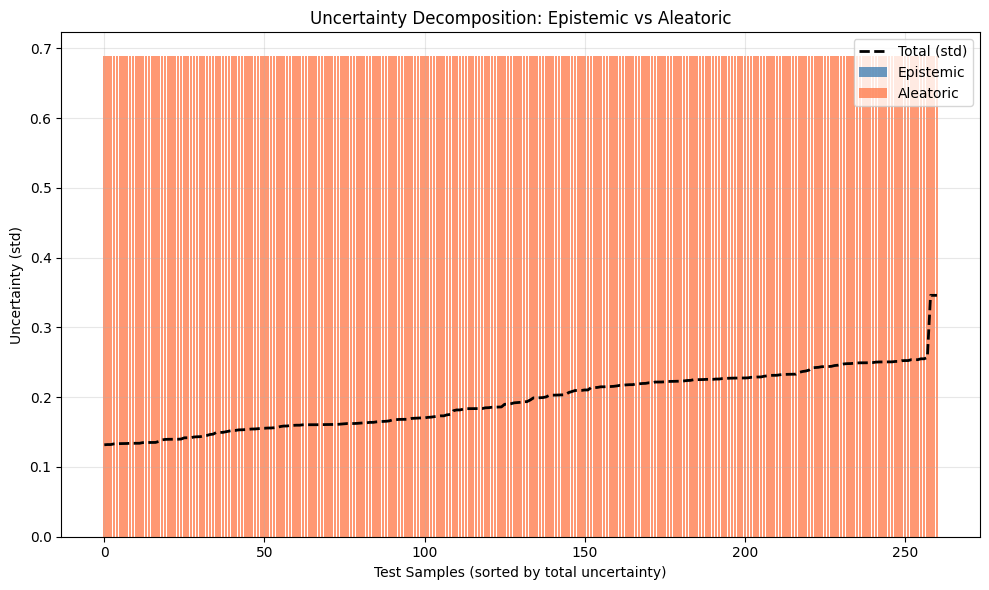

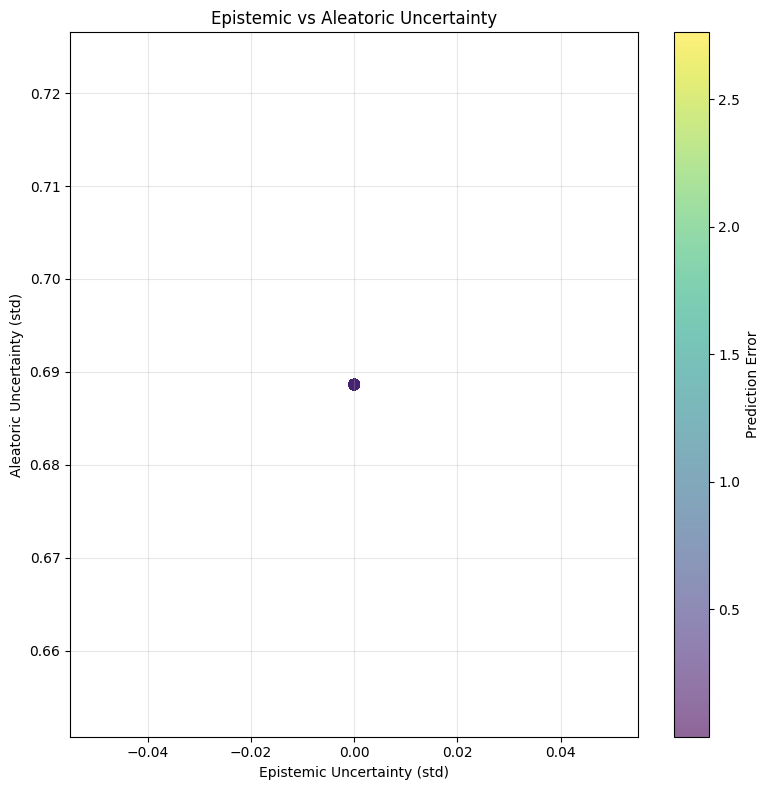

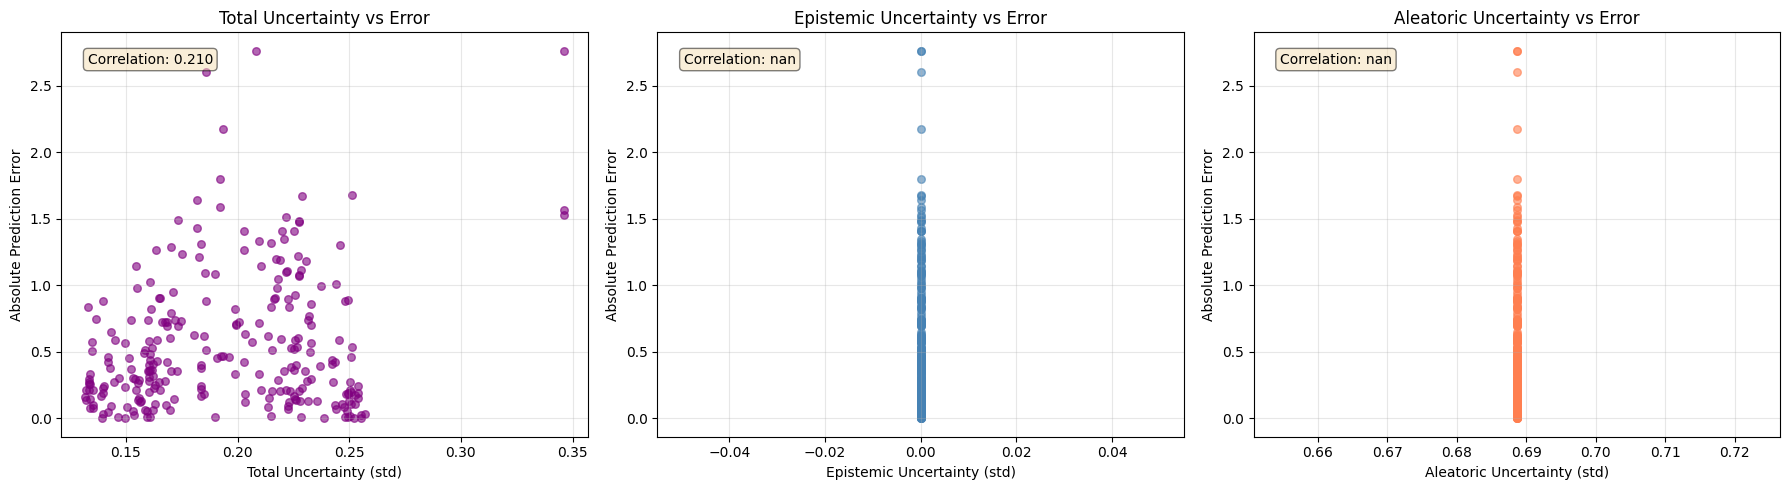

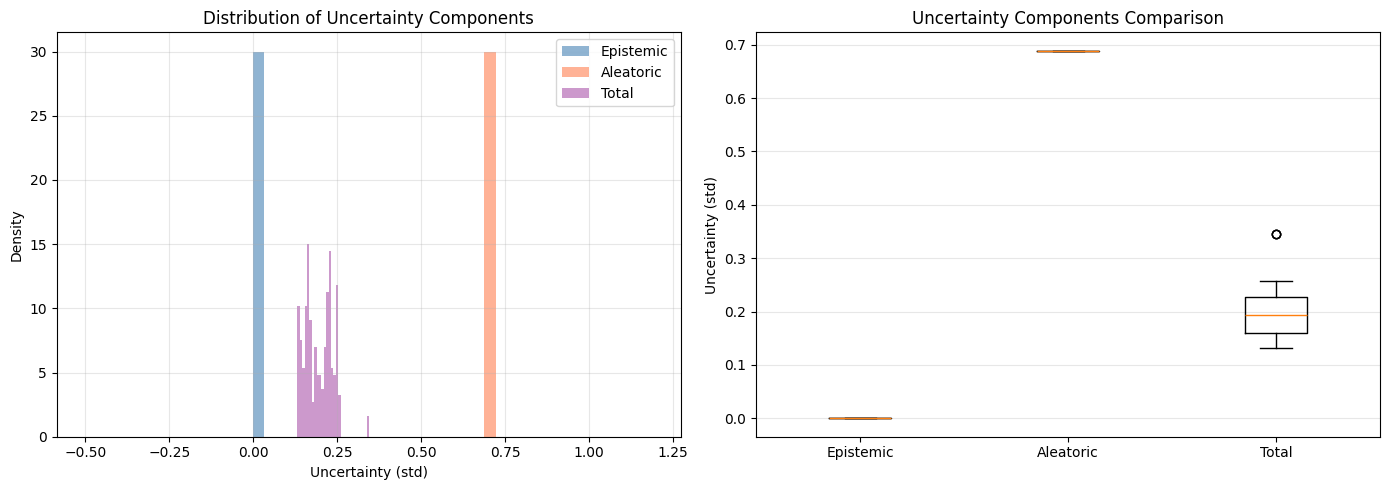

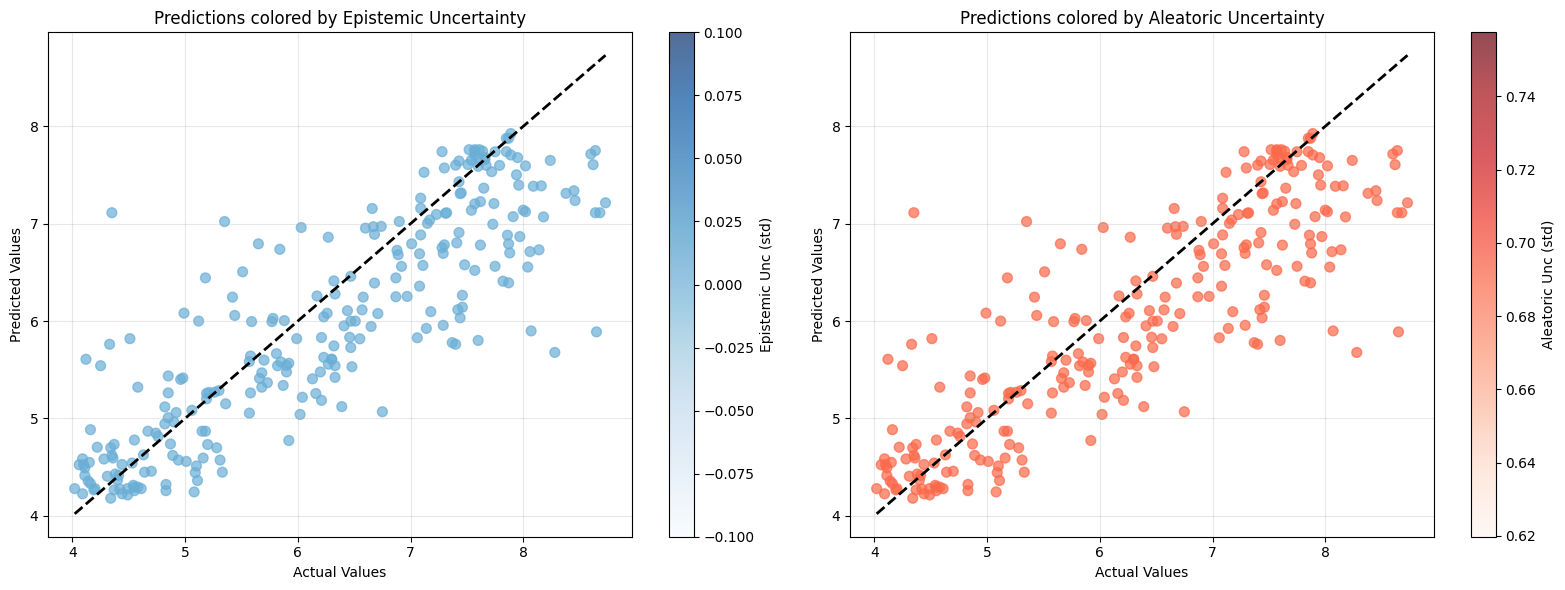


All uncertainty decomposition plots saved to 'model_evaluation_plots' directory


In [64]:
# Visualize Uncertainty Decomposition

def plot_uncertainty_decomposition(uncertainty_results, y_test, save_dir='model_evaluation_plots'):
    """
    Create comprehensive visualizations for uncertainty decomposition.
    """
    mean_pred = uncertainty_results['mean_predictions']
    total_unc = np.sqrt(uncertainty_results['total_uncertainty'])
    epistemic_unc = np.sqrt(uncertainty_results['epistemic_uncertainty'])
    aleatoric_unc = np.sqrt(uncertainty_results['aleatoric_uncertainty'])
    
    errors = np.abs(mean_pred - y_test)
    
    os.makedirs(save_dir, exist_ok=True)
    
    # Create individual plots
    
    # 1. Stacked uncertainty components
    fig, ax = plt.subplots(figsize=(10, 6))
    indices = np.arange(len(y_test))
    sort_idx = np.argsort(total_unc)
    
    ax.bar(indices, epistemic_unc[sort_idx], label='Epistemic', color='steelblue', alpha=0.8)
    ax.bar(indices, aleatoric_unc[sort_idx], bottom=epistemic_unc[sort_idx], 
           label='Aleatoric', color='coral', alpha=0.8)
    ax.plot(indices, total_unc[sort_idx], 'k--', linewidth=2, label='Total (std)')
    ax.set_xlabel('Test Samples (sorted by total uncertainty)')
    ax.set_ylabel('Uncertainty (std)')
    ax.set_title('Uncertainty Decomposition: Epistemic vs Aleatoric')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'uncertainty_decomposition_stacked.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Scatter: Epistemic vs Aleatoric
    fig, ax = plt.subplots(figsize=(8, 8))
    scatter = ax.scatter(epistemic_unc, aleatoric_unc, c=errors, 
                        cmap='viridis', alpha=0.6, s=50)
    ax.set_xlabel('Epistemic Uncertainty (std)')
    ax.set_ylabel('Aleatoric Uncertainty (std)')
    ax.set_title('Epistemic vs Aleatoric Uncertainty')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Prediction Error')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'epistemic_vs_aleatoric.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Uncertainty components vs prediction error
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].scatter(total_unc, errors, alpha=0.6, color='purple', s=30)
    axes[0].set_xlabel('Total Uncertainty (std)')
    axes[0].set_ylabel('Absolute Prediction Error')
    axes[0].set_title('Total Uncertainty vs Error')
    axes[0].grid(True, alpha=0.3)
    corr_total = np.corrcoef(total_unc, errors)[0, 1]
    axes[0].text(0.05, 0.95, f'Correlation: {corr_total:.3f}', 
                transform=axes[0].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[1].scatter(epistemic_unc, errors, alpha=0.6, color='steelblue', s=30)
    axes[1].set_xlabel('Epistemic Uncertainty (std)')
    axes[1].set_ylabel('Absolute Prediction Error')
    axes[1].set_title('Epistemic Uncertainty vs Error')
    axes[1].grid(True, alpha=0.3)
    corr_epistemic = np.corrcoef(epistemic_unc, errors)[0, 1]
    axes[1].text(0.05, 0.95, f'Correlation: {corr_epistemic:.3f}', 
                transform=axes[1].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[2].scatter(aleatoric_unc, errors, alpha=0.6, color='coral', s=30)
    axes[2].set_xlabel('Aleatoric Uncertainty (std)')
    axes[2].set_ylabel('Absolute Prediction Error')
    axes[2].set_title('Aleatoric Uncertainty vs Error')
    axes[2].grid(True, alpha=0.3)
    corr_aleatoric = np.corrcoef(aleatoric_unc, errors)[0, 1]
    axes[2].text(0.05, 0.95, f'Correlation: {corr_aleatoric:.3f}', 
                transform=axes[2].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'uncertainty_vs_error.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Distribution comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(epistemic_unc, bins=30, alpha=0.6, color='steelblue', 
                label='Epistemic', density=True)
    axes[0].hist(aleatoric_unc, bins=30, alpha=0.6, color='coral', 
                label='Aleatoric', density=True)
    axes[0].hist(total_unc, bins=30, alpha=0.4, color='purple', 
                label='Total', density=True)
    axes[0].set_xlabel('Uncertainty (std)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Distribution of Uncertainty Components')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    uncertainty_data = [epistemic_unc, aleatoric_unc, total_unc]
    axes[1].boxplot(uncertainty_data, labels=['Epistemic', 'Aleatoric', 'Total'])
    axes[1].set_ylabel('Uncertainty (std)')
    axes[1].set_title('Uncertainty Components Comparison')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'uncertainty_distributions.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. Predictions colored by uncertainty type
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Color by epistemic
    scatter1 = axes[0].scatter(y_test, mean_pred, c=epistemic_unc, 
                              cmap='Blues', alpha=0.7, s=50)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'k--', lw=2)
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title('Predictions colored by Epistemic Uncertainty')
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Epistemic Unc (std)')
    axes[0].grid(True, alpha=0.3)
    
    # Color by aleatoric
    scatter2 = axes[1].scatter(y_test, mean_pred, c=aleatoric_unc, 
                              cmap='Reds', alpha=0.7, s=50)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'k--', lw=2)
    axes[1].set_xlabel('Actual Values')
    axes[1].set_ylabel('Predicted Values')
    axes[1].set_title('Predictions colored by Aleatoric Uncertainty')
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Aleatoric Unc (std)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'predictions_by_uncertainty_type.pdf'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nAll uncertainty decomposition plots saved to '{save_dir}' directory")

# Generate visualizations
plot_uncertainty_decomposition(uncertainty_results, y_test)